<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/RNN/Simple_Recurrent_Neural_Network_NLP_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

In [ ]:
text = "This is GeeksforGeeks a software training institute"
#chars = sorted(list(set(text)))
chars = sorted(set(text))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}

In [ ]:
len(text)

51

In [ ]:
len(chars)

17

In [ ]:
chars

[' ',
 'G',
 'T',
 'a',
 'e',
 'f',
 'g',
 'h',
 'i',
 'k',
 'n',
 'o',
 'r',
 's',
 't',
 'u',
 'w']

In [ ]:
char_to_index

{' ': 0,
 'G': 1,
 'T': 2,
 'a': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'k': 9,
 'n': 10,
 'o': 11,
 'r': 12,
 's': 13,
 't': 14,
 'u': 15,
 'w': 16}

In [ ]:
index_to_char

{0: ' ',
 1: 'G',
 2: 'T',
 3: 'a',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'k',
 10: 'n',
 11: 'o',
 12: 'r',
 13: 's',
 14: 't',
 15: 'u',
 16: 'w'}

In [ ]:
seq_length = 3
sequences = []
labels = []

for i in range(len(text) - seq_length):
	seq = text[i:i+seq_length]
	label = text[i+seq_length]
	sequences.append([char_to_index[char] for char in seq])
	labels.append(char_to_index[label])

In [ ]:
len(sequences)

48

In [ ]:
sequences[0:6]

[[2, 7, 8], [7, 8, 13], [8, 13, 0], [13, 0, 8], [0, 8, 13], [8, 13, 0]]

In [ ]:
len(labels)

48

In [ ]:
labels[0:10]

[13, 0, 8, 13, 0, 1, 4, 4, 9, 13]

In [ ]:
X = np.array(sequences)
y = np.array(labels)

X_one_hot = tf.one_hot(X, len(chars))
y_one_hot = tf.one_hot(y, len(chars))

In [ ]:
len(X_one_hot)

48

In [ ]:
X_one_hot[0]

<tf.Tensor: shape=(3, 17), dtype=float32, numpy=
array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0.]], dtype=float32)>

In [ ]:
len(y_one_hot)

48

In [ ]:
y_one_hot[0]

<tf.Tensor: shape=(17,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
      dtype=float32)>

In [ ]:
model = Sequential()
model.add(SimpleRNN(units=50, input_shape=(seq_length, len(chars)), activation='relu'))
model.add(Dense(len(chars), activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, 50)                3400      
                                                                 
 dense_1 (Dense)             (None, 17)                867       
                                                                 
Total params: 4267 (16.67 KB)
Trainable params: 4267 (16.67 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
h=model.fit(X_one_hot, y_one_hot, epochs=100, verbose=2)

Epoch 1/100
2/2 - 1s - loss: 2.8276 - accuracy: 0.0833 - 1s/epoch - 745ms/step
Epoch 2/100
2/2 - 0s - loss: 2.8028 - accuracy: 0.1250 - 14ms/epoch - 7ms/step
Epoch 3/100
2/2 - 0s - loss: 2.7818 - accuracy: 0.1458 - 12ms/epoch - 6ms/step
Epoch 4/100
2/2 - 0s - loss: 2.7609 - accuracy: 0.1458 - 13ms/epoch - 6ms/step
Epoch 5/100
2/2 - 0s - loss: 2.7412 - accuracy: 0.1667 - 11ms/epoch - 6ms/step
Epoch 6/100
2/2 - 0s - loss: 2.7218 - accuracy: 0.1875 - 11ms/epoch - 6ms/step
Epoch 7/100
2/2 - 0s - loss: 2.7031 - accuracy: 0.2292 - 12ms/epoch - 6ms/step
Epoch 8/100
2/2 - 0s - loss: 2.6842 - accuracy: 0.2708 - 14ms/epoch - 7ms/step
Epoch 9/100
2/2 - 0s - loss: 2.6652 - accuracy: 0.2708 - 12ms/epoch - 6ms/step
Epoch 10/100
2/2 - 0s - loss: 2.6463 - accuracy: 0.2708 - 13ms/epoch - 7ms/step
Epoch 11/100
2/2 - 0s - loss: 2.6268 - accuracy: 0.2708 - 12ms/epoch - 6ms/step
Epoch 12/100
2/2 - 0s - loss: 2.6073 - accuracy: 0.2708 - 12ms/epoch - 6ms/step
Epoch 13/100
2/2 - 0s - loss: 2.5870 - accuracy: 

In [ ]:
def plot_acc_loss(h):

  plt.figure(figsize = (11,5))
  plt.subplot(1,2,1)
  plt.plot(h.history['loss'], label = 'Treino')
  plt.xlabel('Épocas')
  plt.ylabel('Função Custo')
  plt.title('loss')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.grid()
  plt.subplot(1,2,2)
  plt.plot(h.history['accuracy'], label = 'Treino')
  plt.xlabel('Épocas')
  plt.ylabel('Acurácia')
  plt.title('accuracy')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.tight_layout()
  plt.grid()
  plt.show()

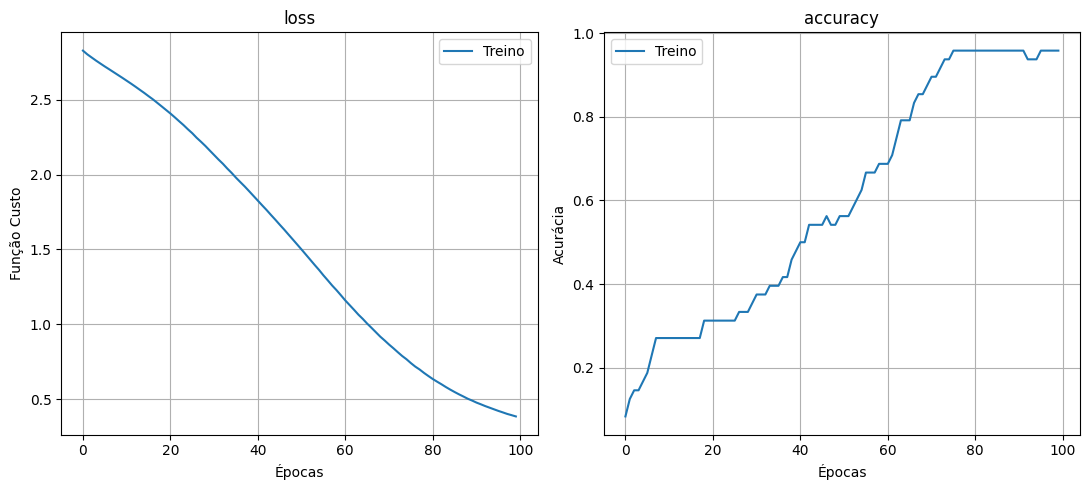

In [ ]:
plot_acc_loss(h)

In [ ]:
start_seq = "is G"
generated_text = start_seq

for i in range(30):
	x = np.array([[char_to_index[char] for char in generated_text[-seq_length:]]])
	x_one_hot = tf.one_hot(x, len(chars))
	prediction = model.predict(x_one_hot, verbose='silent')
	next_index = np.argmax(prediction)
	next_char = index_to_char[next_index]
	generated_text += next_char

print("Generated Text:")
print(generated_text)

Generated Text:
is Geeks a software training insti


#Exercícios
1. Aumentar o número de épocas de treinamento até que a função custo se estabilize
1. Verificar se as predições são acertivas
1. Modificar o texto de treinamento para: "Uma rede neural recorrente (RNN) é um tipo de rede neural artificial que usa dados sequenciais ou de séries temporais e pode ser utilizada para predições futuras"
1. Treinar a rede e verificar a eficiência das predições
1. Modificar o número de unidades da camada SimpleRNN: *units* = 10, 30, 60 e 100. Verificar e comparar os resultados
1. Alterar a quantidade de dados dos lotes de treinamento: *seq_length* = 5, 7 e 10.  Verificar e comparar os resultados
1. Inserir mais uma camada oculta SimpleRNN com o mesmo número de unidades da primeira camada, que deve ter o parâmetro `return_sequences=True`. Verificar e comparar os resultados

##Referências
[1] https://www.geeksforgeeks.org/introduction-to-recurrent-neural-network/

[2] https://machinelearningmastery.com/understanding-simple-recurrent-neural-networks-in-keras/

[3] https://www.tensorflow.org/guide/keras/working_with_rnns

[4] https://www.simplilearn.com/tutorials/deep-learning-tutorial/rnn

[5] https://www.datacamp.com/tutorial/tutorial-for-recurrent-neural-network

[6] https://github.com/bilkosem/simple-rnn_from_scratch